# Proyecto Data Mining - CRISP-DM

**Integrantes:** Flavio Henriquez / Bastian Bianchi  
**Docente:** Italo Bonnet

## 1. Entendimiento del Negocio

Esta fase tiene por finalidad definir el problema de estudio, justificar su relevancia y delimitar el alcance del analisis. En coherencia con la metodologia CRISP-DM, el proposito inicial no es construir un modelo de manera inmediata, sino comprender con claridad que valor puede aportar el estudio de las precipitaciones diarias, que informacion se encuentra disponible, cuales son las principales restricciones del conjunto de datos y bajo que criterios se evaluara la pertinencia del trabajo desarrollado.


### 1.1 Contexto

Chile presenta una marcada diversidad climatica y geografica. En su territorio coexisten zonas deserticas, altiplanicas, valles interiores, sectores costeros y areas de clima mediterraneo, por lo que la precipitacion no se distribuye de manera homogenea ni en el espacio ni en el tiempo. Esta variabilidad convierte el estudio de las lluvias en un problema relevante para la gestion hidrica, la planificacion agricola, el monitoreo meteorologico, la prevencion de eventos extremos y la toma de decisiones territoriales.

El presente proyecto utiliza un dataset de precipitaciones diarias registradas por estaciones meteorologicas chilenas. La granularidad diaria resulta especialmente pertinente, ya que permite observar no solo la magnitud de la lluvia, sino tambien la frecuencia de ocurrencia de los eventos, su concentracion estacional y las diferencias existentes entre estaciones. En consecuencia, el conjunto ofrece una perspectiva mas precisa que un agregado mensual, especialmente cuando se busca identificar dias sin precipitacion, eventos intensos y patrones temporales recurrentes.

Desde una perspectiva aplicada, el valor del analisis radica en transformar registros operacionales en informacion util para comprender el comportamiento de la precipitacion y dejar una base consistente para etapas posteriores del proyecto. No obstante, tambien es necesario reconocer que el dataset no incorpora todas las variables climaticas que podrian influir en el fenomeno. Por ello, en esta primera fase el objetivo central consiste en caracterizar adecuadamente el caso, delimitar su alcance y justificar las decisiones analiticas que orientaran las siguientes etapas del trabajo.


### 1.2 Datos relevantes

El analisis se sustenta en el archivo `dataset_precipitaciones_diarias_chile_COMPLETO.csv`, que contiene la serie diaria principal, y puede complementarse con `Set de datos/getEstacionesRedEma.json`, el cual permite asociar a los codigos tecnicos nombres descriptivos de estaciones, regiones y zonas geograficas. Esta complementacion resulta relevante porque mejora la interpretacion territorial de los datos y facilita su lectura desde una perspectiva de negocio.

Con el fin de ordenar la presentacion, primero se resume el alcance general del conjunto y, a continuacion, se expone el diccionario de variables considerado en esta fase.

**Resumen del conjunto**

| Aspecto | Valor observado | Relevancia para el proyecto |
| --- | --- | --- |
| Fuente principal | `dataset_precipitaciones_diarias_chile_COMPLETO.csv` | Contiene la base diaria usada para el analisis |
| Metadata complementaria | `Set de datos/getEstacionesRedEma.json` | Permite enriquecer los codigos con nombres de estacion, region y zona geografica |
| Granularidad | 1 registro por estacion y por dia | Permite analizar frecuencia e intensidad diaria de precipitaciones |
| Periodo cubierto | 2021-01-01 a 2025-12-31 | Entrega continuidad temporal reciente de 5 anos |
| Cantidad de registros | 187,876 filas | Da volumen suficiente para detectar patrones temporales y territoriales |
| Variables originales | 10 columnas | Incluye atributos de ubicacion, tiempo y precipitacion |
| Estaciones meteorologicas | 109 | Aporta diversidad espacial y comparacion entre puntos de medicion |
| Regiones representadas | 16 | Entrega cobertura territorial amplia dentro de Chile |
| Variable objetivo | `agua_caida` | Es la magnitud que se desea comprender y eventualmente predecir |
| Nulos en `agua_caida` | 17,063 registros (9.08%) | Obliga a revisar estrategia de limpieza o imputacion antes de modelar |

Los atributos disponibles describen tanto la ubicacion de la estacion como el momento temporal exacto del registro. En consecuencia, el siguiente diccionario resume las variables base sobre las cuales se desarrolla el problema analitico.

**Diccionario de variables**

| Variable | Descripcion | Tipo analitico | Rol dentro del problema |
| --- | --- | --- | --- |
| `codigo_estacion` | Identificador de la estacion meteorologica | Categorica nominal codificada numericamente | Permite distinguir comportamiento local por estacion |
| `region` | Codigo de la region asociada a la estacion | Categorica nominal codificada numericamente | Resume pertenencia territorial |
| `altura` | Altitud de la estacion en metros | Numerica discreta | Puede influir en el patron de precipitacion |
| `latitud` | Coordenada de latitud | Numerica continua | Captura posicion geografica norte-sur |
| `longitud` | Coordenada de longitud | Numerica continua | Captura posicion geografica este-oeste |
| `anio` | Ano del registro | Numerica discreta temporal | Permite analizar cambios interanuales |
| `mes` | Mes del registro | Numerica discreta temporal | Representa estacionalidad anual |
| `dia` | Dia del mes | Numerica discreta temporal | Permite trabajar a nivel diario |
| `fecha` | Fecha completa del registro | Temporal | Facilita orden cronologico y creacion de nuevas variables |
| `agua_caida` | Milimetros de precipitacion observados en el dia | Numerica continua | Variable objetivo del analisis |

**Analisis.** La adopcion de un dataset diario modifica de manera sustantiva el alcance del problema respecto de una base agregada mensualmente. En este caso, no solo interesa describir montos acumulados, sino tambien examinar la frecuencia de los dias con precipitacion, la concentracion de eventos intensos y la continuidad temporal de cada estacion. Sobre el total de registros, el 67.68% presenta `agua_caida = 0`, el 23.24% registra precipitacion positiva y el 9.08% corresponde a valores nulos en la variable objetivo. En terminos analiticos, esta combinacion de granularidad diaria, cobertura territorial y volumen de observaciones convierte al conjunto en una base pertinente para caracterizacion descriptiva y para una eventual proyeccion predictiva posterior.


### 1.3 Hipotesis y tesis consideradas

A partir del contexto del problema y de la estructura del dataset, se plantean las siguientes hipotesis de trabajo:

- La precipitacion diaria presenta un comportamiento estacional identificable, por lo que `mes`, `fecha` y posibles variables derivadas del calendario deberian explicar una parte relevante de la variacion observada en `agua_caida`.
- La ubicacion geografica de cada estacion, representada por `latitud`, `longitud`, `altura` y `region`, influye en la intensidad y en la frecuencia de las precipitaciones.
- Existen diferencias estructurales entre estaciones meteorologicas; por lo tanto, `codigo_estacion` no solo actua como identificador, sino que tambien sintetiza condiciones locales de relieve, exposicion y microclima.
- La base diaria presenta una alta concentracion de dias sin precipitacion, por lo que la distribucion de la variable objetivo sera asimetrica y exigira especial cuidado interpretativo.
- Los valores faltantes de `agua_caida` deben revisarse antes de cualquier etapa posterior, ya que una concentracion no aleatoria por estacion o por periodo podria sesgar las conclusiones del analisis.
- Como proyeccion del proyecto, el caso puede formularse posteriormente como una tarea predictiva de regresion orientada a estimar la precipitacion diaria en milimetros.

**Analisis.** Las hipotesis propuestas son consistentes con el enfoque de CRISP-DM revisado en el material de apoyo, ya que parten desde una comprension razonada del problema antes de avanzar hacia etapas de preparacion o modelamiento. En este caso, la estacionalidad, la heterogeneidad territorial y la asimetria de la variable objetivo no constituyen detalles secundarios, sino rasgos centrales del fenomeno estudiado. Por ello, en la fase siguiente sera especialmente importante examinar la distribucion de los nulos, la capacidad explicativa de las variables disponibles y la conveniencia de construir atributos temporales o territoriales mas expresivos.


### 1.4 KPI relevantes

En una entrega centrada en las primeras fases de CRISP-DM, los KPI mas pertinentes no corresponden todavia al rendimiento de un modelo final, sino a indicadores que permitan evaluar si el problema ha sido correctamente delimitado y si la base presenta condiciones adecuadas para continuar con el proceso analitico.

| KPI | Valor o criterio actual | Por que es relevante |
| --- | --- | --- |
| Cobertura temporal del dataset | 2021-01-01 a 2025-12-31 | Confirma que el analisis abarca 5 anos recientes y no solo una temporada aislada |
| Cobertura territorial | 109 estaciones en 16 regiones | Mide si el problema tiene representatividad geografica suficiente |
| Completitud de `agua_caida` | 90.92% con dato disponible | Permite saber cuanta informacion util hay para analizar o modelar |
| Registros con `agua_caida = 0` | 67.68% del total | Advierte que la variable objetivo esta altamente concentrada en ausencia de lluvia |
| Registros con precipitacion positiva | 23.24% del total | Ayuda a dimensionar la frecuencia real de eventos de lluvia |
| Duplicados por estacion-fecha | 0 | Indica consistencia basica de la unidad de analisis diaria |

Si el proyecto avanzara hacia una etapa predictiva de regresion, las metricas tecnicas mas coherentes con lo revisado en clases serian las siguientes:

- `RMSE`, debido a que penaliza con mayor intensidad los errores elevados y se encuentra explicitamente considerado en la estructura del curso.
- `r`, porque permite evaluar el grado de asociacion entre los valores reales y los valores estimados en una futura etapa de evaluacion.

**Analisis.** Estos indicadores articulan la comprension del negocio con las decisiones tecnicas sin anticipar de manera excesiva contenidos posteriores. Por ejemplo, una base con amplia cobertura territorial pero con menor completitud en la variable objetivo puede resultar adecuada para caracterizar patrones generales, aunque no necesariamente para sustentar un modelamiento confiable sin una etapa previa de limpieza. Asimismo, en un escenario diario con alta presencia de ceros, la futura evaluacion del modelo no debiera limitarse a un promedio general de error, sino considerar tambien su comportamiento frente a episodios de precipitacion mas intensos.


### 1.5 Problema de negocio (Analisis y proyeccion predictiva)

El problema de negocio consiste en comprender y dejar preparada una base analitica que permita explicar el comportamiento de la precipitacion diaria en estaciones meteorologicas chilenas. El valor esperado del proyecto radica en aportar informacion util para la gestion hidrica, el monitoreo de condiciones climaticas, la planificacion territorial y el analisis de riesgo asociado a periodos secos o a eventos de lluvia intensa.

La unidad de analisis del proyecto corresponde a cada combinacion `estacion-dia`. En dicho nivel, la variable objetivo es `agua_caida`, medida en milimetros, mientras que las variables disponibles describen la ubicacion geografica de la estacion y el momento temporal del registro. Desde la perspectiva de mineria de datos, el caso puede proyectarse principalmente como un problema de regresion supervisada orientado a estimar la precipitacion diaria a partir de atributos espaciales y temporales.

**Analisis.** Dado que esta entrega prioriza el entendimiento del negocio y de los datos, el objetivo no consiste en prometer un modelo final, sino en formular correctamente el caso y preparar la base con criterios tecnicamente defendibles. La principal fortaleza del dataset diario es que permite pasar de una mirada agregada a una lectura mas fina del fenomeno; su principal limitacion es que no incorpora otras variables meteorologicas potencialmente explicativas. En consecuencia, cualquier desarrollo predictivo posterior debera interpretarse como una aproximacion sustentada en informacion temporal, territorial e historica. Aun con dicha restriccion, el problema se encuentra adecuadamente planteado y ofrece una base razonable para continuar con las siguientes fases del proceso.


## 2. Entendimiento de los Datos

En esta fase se realiza una exploracion estructurada del dataset con el fin de identificar tipos de variables, valores faltantes, posibles outliers, distribuciones basicas, correlaciones y patrones relevantes. En coherencia con el material de apoyo, el objetivo no es solo describir los datos, sino tambien interpretar su calidad y anticipar decisiones de preparacion que permitan continuar el proceso de mineria de datos con mayor solidez.


### 2.1 Identificar Tipos de variables/atributos


En esta subseccion se distingue entre el tipo tecnico detectado por `pandas` y el tipo analitico que realmente cumple cada atributo dentro del problema. Esta distincion es importante porque varias columnas aparecen como numericas, pero conceptualmente funcionan como identificadores o categorias nominales y, por lo tanto, no deben interpretarse como magnitudes continuas.


In [ ]:
# Si necesitas instalar dependencias en este notebook:
# !pip install "pandas" "numpy" "matplotlib" "scikit-learn"

from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", None)

base_path = Path("dataset_precipitaciones_diarias_chile_COMPLETO.csv")
meta_path = Path("Set de datos") / "getEstacionesRedEma.json"


En esta primera celda solo se preparan las dependencias, la configuracion visual y las rutas de trabajo. Si el entorno no dispone de alguna libreria necesaria, la instalacion puede realizarse aparte, pero no se deja embebida dentro del codigo para mantener el flujo del notebook mas limpio.


In [ ]:
def heatmap_df(data, title, cmap="Blues", figsize=(8, 5), decimals=2, xlabel="Eje X", ylabel="Eje Y", cbar_label="Valor"):
    fig, ax = plt.subplots(figsize=figsize)
    matrix = data.astype(float).values
    im = ax.imshow(matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index)
    for row in range(data.shape[0]):
        for col in range(data.shape[1]):
            value = matrix[row, col]
            ax.text(col, row, f"{value:.{decimals}f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(cbar_label)
    plt.tight_layout()
    plt.show()


La funcion `heatmap_df` queda separada porque se reutiliza varias veces en el notebook para correlaciones y patrones. Tenerla aislada ayuda a entender que es una herramienta de visualizacion transversal y no parte de un solo analisis puntual.


In [ ]:
def region_to_macrozone(region_code):
    if region_code in [15, 1, 2, 3, 4]:
        return "Norte"
    if region_code in [5, 13, 6, 7]:
        return "Centro"
    if region_code in [16, 8, 9, 14, 10]:
        return "Sur"
    if region_code in [11, 12]:
        return "Austral"
    return "Otra"


Primero se dejan preparadas las librerias, funciones auxiliares y rutas de trabajo. Esta separacion ayuda a que la carga y el enriquecimiento del dataset se entiendan como pasos distintos y no como una sola celda extensa.


In [ ]:
df_csv = pd.read_csv(base_path)

print(f"Shape base CSV: {df_csv.shape}")
display(df_csv.head())


La lectura inicial del CSV permite verificar el tamaño de la serie diaria antes de mezclarla con metadata externa. Este paso deja claro cual es la fuente principal del analisis.


In [ ]:
meta_json = json.loads(meta_path.read_text(encoding="utf-8"))
meta_df = (
    pd.DataFrame(meta_json["datosEstacion"])[
        ["codigoNacional", "region", "nombreEstacion", "NombreRegion", "zonaGeografica"]
    ]
    .rename(
        columns={
            "codigoNacional": "codigo_estacion",
            "nombreEstacion": "nombre_estacion",
            "NombreRegion": "nombre_region",
            "zonaGeografica": "zona_geografica",
        }
    )
    .drop_duplicates(subset=["codigo_estacion", "region"])
)

print(f"Shape metadata estaciones: {meta_df.shape}")
display(meta_df.head())


En este punto todavia existen dos fuentes separadas: la serie diaria y la metadata descriptiva. La segunda es clave porque transforma codigos tecnicos en nombres de estacion, region y zona geografica, lo que vuelve mucho mas interpretable el analisis posterior.


In [ ]:
df = (
    df_csv.merge(meta_df, on=["codigo_estacion", "region"], how="left")
          .sort_values(["codigo_estacion", "fecha"])
          .reset_index(drop=True)
)
df["fecha"] = pd.to_datetime(df["fecha"])

print(f"Dimension del dataset enriquecido: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Periodo disponible: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"Estaciones con metadata: {df['nombre_estacion'].nunique()}")
print(f"Regiones representadas: {df['nombre_region'].nunique()}")
display(df.head())


Una vez realizado el merge, la base ya puede analizarse como un conjunto enriquecido. Desde aqui en adelante no solo tenemos precipitacion y coordenadas, sino tambien contexto territorial legible para interpretar patrones por estacion y por region.


In [ ]:
resumen_base = pd.DataFrame(
    {
        "dtype_pandas": df.dtypes.astype(str),
        "valores_unicos": df.nunique(dropna=False),
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "valores_unicos"], ascending=[False, False])

display(resumen_base)


Este resumen tecnico permite mirar rapidamente la estructura real de cada columna: tipo detectado, cardinalidad y presencia de nulos. Es un paso util antes de decidir que variables deben tratarse como identificadores, cuales como predictores y cuales requieren limpieza.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
resumen_base["valores_unicos"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Cantidad de valores unicos por variable")
ax.set_xlabel("Cantidad de valores unicos")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


In [ ]:
clasificacion_variables = pd.DataFrame(
    {
        "variable": [
            "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
            "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
        ],
        "tipo_analitico": [
            "Categorica nominal codificada", "Categorica nominal", "Categorica nominal codificada",
            "Categorica nominal", "Categorica nominal", "Numerica discreta", "Numerica continua",
            "Numerica continua", "Numerica discreta temporal", "Numerica discreta temporal",
            "Numerica discreta temporal", "Temporal", "Numerica continua"
        ],
        "rol_en_el_proyecto": [
            "Identificador tecnico de estacion", "Identificador descriptivo de estacion",
            "Codigo territorial", "Referencia territorial descriptiva", "Contexto geografico agregado",
            "Predictor geografico", "Predictor geografico", "Predictor geografico",
            "Predictor temporal", "Predictor temporal", "Predictor temporal",
            "Secuencia cronologica", "Variable objetivo"
        ],
    }
)

display(clasificacion_variables)


**Analisis.** El dataset enriquecido queda compuesto por 13 variables: tres categoricas textuales, dos codigos numericos de naturaleza nominal, seis variables numericas de apoyo analitico, una variable temporal completa (`fecha`) y la variable objetivo `agua_caida`. Un punto metodologico importante es que `codigo_estacion` y `region` no deben interpretarse como magnitudes continuas, ya que sus valores expresan etiquetas y no distancias reales entre categorias. La incorporacion de `nombre_estacion`, `nombre_region` y `zona_geografica` mejora ademas la interpretacion del caso desde una perspectiva territorial.


### 2.2 Identificar Nulos


Tal como se enfatiza en el material de apoyo, la revision de valores faltantes debe realizarse antes de cualquier transformacion relevante. En esta etapa no solo interesa cuantificar si existen nulos, sino tambien identificar en que variable se concentran y si su distribucion sugiere un comportamiento aleatorio o un patron sistematico.


In [5]:
tabla_nulos = pd.DataFrame(
    {
        "nulos": df.isnull().sum(),
        "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    }
).sort_values(["nulos", "porcentaje_nulos"], ascending=False)

display(tabla_nulos)


,nulos,porcentaje_nulos
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
longitud,0,0.00
anio,0,0.00
mes,0,0.00
dia,0,0.00
fecha,0,0.00


,total,nulos,porcentaje_nulos
nombre_region,,,
AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,10437,1946,18.65
De Los RÃ­os,6569,1156,17.60
TarapacÃ¡,4748,767,16.15
De Los Lagos,16434,2363,14.38
De La AraucanÃ­a,10956,1488,13.58
Coquimbo,15290,1655,10.82
Atacama,6120,614,10.03
Del Libertador Gral. Bernardo O'Higgins,9092,885,9.73
Del BiobÃ­o,8764,851,9.71


,total,nulos,porcentaje_nulos
anio,,,
2021,35606,4215,11.84
2022,35735,3412,9.55
2023,38325,4799,12.52
2024,39162,2954,7.54
2025,39048,1683,4.31


Una vez identificado el panorama general de nulos, conviene bajar el analisis a segmentos concretos. En este caso interesa revisar si la ausencia de `agua_caida` cambia segun region o anio.


In [ ]:
nulos_region = (
    df.groupby("nombre_region")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_values("porcentaje_nulos", ascending=False)
)

nulos_anio = (
    df.groupby("anio")["agua_caida"]
      .agg(total="size", nulos=lambda s: s.isna().sum(), porcentaje_nulos=lambda s: round(s.isna().mean() * 100, 2))
      .sort_index()
)

display(nulos_region.head(10))
display(nulos_anio)


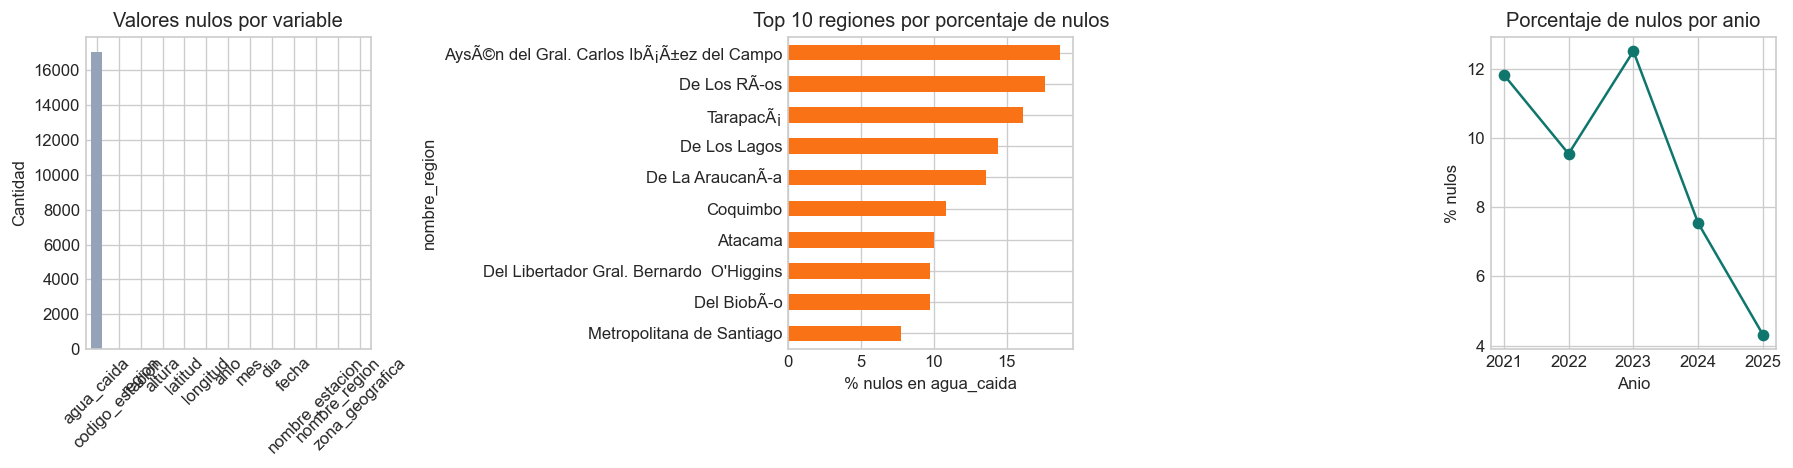

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
tabla_nulos["nulos"].plot(kind="bar", ax=ax, color="#94a3b8")
ax.set_title("Valores nulos por variable")
ax.set_xlabel("Variable")
ax.set_ylabel("Cantidad")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


Despues del panorama general, conviene visualizar la concentracion de nulos por region y por anio. Esto permite evaluar si el problema de completitud esta distribuido de forma uniforme o si afecta con mas fuerza a ciertos segmentos.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

nulos_region.head(10)["porcentaje_nulos"].sort_values().plot(kind="barh", ax=axes[0], color="#f97316")
axes[0].set_title("Top 10 regiones por porcentaje de nulos")
axes[0].set_xlabel("% nulos en agua_caida")
axes[0].set_ylabel("Region")

nulos_anio["porcentaje_nulos"].plot(marker="o", ax=axes[1], color="#0f766e")
axes[1].set_title("Porcentaje de nulos por anio")
axes[1].set_xlabel("Anio")
axes[1].set_ylabel("% nulos")

plt.tight_layout()
plt.show()


**Analisis.** El diagnostico muestra que los valores faltantes se concentran exclusivamente en `agua_caida`, con 17,063 registros nulos equivalentes al 9.08% del total. Esto significa que la calidad de los predictores es alta, pero la variable objetivo no esta completamente disponible. Ademas, la ausencia de datos no parece completamente aleatoria: regiones como Aysen del Gral. Carlos Ibanez del Campo (18.65%), De Los Rios (17.60%) y Tarapaca (16.15%) presentan porcentajes mas altos, y por anio los mayores niveles se observan en 2023 (12.52%) y 2021 (11.84%). En consecuencia, la estrategia de limpieza no debe asumir automaticamente que los nulos son irrelevantes, sino tratarlos con cuidado en funcion del objetivo del analisis.


### 2.3 Identificar Outliers


La deteccion de outliers debe realizarse con criterio estadistico y tambien con criterio de dominio. En precipitaciones diarias es esperable encontrar una distribucion muy asimetrica, con gran cantidad de ceros y pocos eventos intensos. Por ello, ademas del criterio IQR, conviene revisar percentiles altos y observar explicitamente los registros extremos antes de decidir si deben corregirse, conservarse o marcarse para revision.


In [ ]:
distribucion_lluvia = pd.DataFrame(
    {
        "indicador": ["Dias sin precipitacion", "Dias con precipitacion", "Registros nulos"],
        "porcentaje": [
            round((df["agua_caida"] == 0).mean() * 100, 2),
            round((df["agua_caida"] > 0).mean() * 100, 2),
            round(df["agua_caida"].isna().mean() * 100, 2),
        ],
    }
)

display(distribucion_lluvia)


El primer paso muestra la composicion general de la variable objetivo. Si predominan los ceros, cualquier regla automatica basada solo en dispersion tendera a sobredetectar supuestos outliers, por lo que conviene interpretar con especial cautela los resultados siguientes.


In [ ]:
q1 = df["agua_caida"].quantile(0.25)
q3 = df["agua_caida"].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
p95 = df["agua_caida"].quantile(0.95)
p99 = df["agua_caida"].quantile(0.99)


Con los percentiles y el criterio IQR ya calculados, se resume la magnitud real del problema. Este bloque separa el calculo estadistico del reporte final para que la logica del diagnostico sea mas facil de seguir.


In [ ]:
resumen_outliers = pd.DataFrame(
    {
        "Q1": [round(q1, 2)],
        "Q3": [round(q3, 2)],
        "IQR": [round(iqr, 2)],
        "Limite_superior_IQR": [round(upper, 2)],
        "Percentil_95": [round(p95, 2)],
        "Percentil_99": [round(p99, 2)],
        "Registros_sobre_IQR": [int((df["agua_caida"] > upper).sum())],
        "Registros_sobre_P99": [int((df["agua_caida"] >= p99).sum())],
        "Registros_mayores_100mm": [int((df["agua_caida"] > 100).sum())],
        "Registros_mayores_500mm": [int((df["agua_caida"] > 500).sum())],
    }
)

display(resumen_outliers)


Aqui ya se observa si el limite IQR resulta demasiado sensible para una variable con muchos ceros. Compararlo con percentiles altos permite separar mejor lo que es simplemente lluvia positiva de lo que realmente parece un valor extremo dentro del conjunto.


In [ ]:
extremos_lluvia = (
    df.loc[df["agua_caida"].notna(), ["fecha", "nombre_estacion", "nombre_region", "agua_caida"]]
      .sort_values("agua_caida", ascending=False)
      .head(15)
)

display(extremos_lluvia)


La revision manual de los valores mas altos es importante porque entrega contexto concreto: no es lo mismo un valor alto aislado en una zona muy seca que una observacion intensa en una estacion del sur donde la lluvia frecuente es esperable.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["agua_caida"].dropna(), bins=40, color="#0f766e", edgecolor="white")
axes[0].set_title("Distribucion de agua_caida")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log1p(df["agua_caida"].dropna()), bins=40, color="#2563eb", edgecolor="white")
axes[1].set_title("Distribucion de log1p(agua_caida)")
axes[1].set_xlabel("Escala logaritmica")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


In [ ]:
regiones_box = (
    df.groupby("nombre_region")["agua_caida"]
      .median()
      .sort_values()
      .index
      .tolist()
)
datos_box = [df.loc[df["nombre_region"] == region, "agua_caida"].dropna() for region in regiones_box]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(datos_box, tick_labels=regiones_box, vert=False)
ax.set_title("Boxplot de agua_caida por region")
ax.set_xlabel("Milimetros")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()


**Analisis.** La variable `agua_caida` presenta una distribucion fuertemente sesgada hacia cero. El criterio IQR entrega `Q1 = 0.00`, `Q3 = 0.10` y un limite superior muy bajo, por lo que una gran cantidad de registros queda por encima de ese umbral. En este caso, interpretar todos esos valores como outliers seria incorrecto, ya que el problema no radica en la presencia de errores evidentes sino en la estructura zero-inflated de la variable. Los histogramas y boxplots confirman que existe una cola larga y diferencias territoriales marcadas, por lo que resulta mas razonable marcar eventos extremos para revision que eliminarlos automaticamente.


### 2.4 Transformaciones


Sobre la base del diagnostico anterior, se define un conjunto de trabajo orientado al analisis. Esta etapa no busca todavia optimizar un modelo, sino dejar la informacion en una forma mas interpretable y util para las fases posteriores, manteniendo tanto la trazabilidad territorial como la secuencia temporal de los registros.


In [11]:
columnas_trabajo = [
    "codigo_estacion", "nombre_estacion", "region", "nombre_region", "zona_geografica",
    "altura", "latitud", "longitud", "anio", "mes", "dia", "fecha", "agua_caida"
]

df_trabajo = df[columnas_trabajo].copy()

print("Columnas seleccionadas para el trabajo analitico:")
display(pd.DataFrame({"columnas": df_trabajo.columns}))
display(df_trabajo.head())


Columnas seleccionadas para el trabajo analitico:


,columnas
0,codigo_estacion
1,nombre_estacion
2,region
3,nombre_region
4,zona_geografica
5,altura
6,latitud
7,longitud
8,anio
9,mes


,codigo_estacion,nombre_estacion,region,nombre_region,zona_geografica,altura,latitud,longitud,anio,mes,dia,fecha,agua_caida
0,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,1,2023-01-01,NaN
1,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,2,2023-01-02,NaN
2,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,3,2023-01-03,NaN
3,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,4,2023-01-04,NaN
4,170001,Visviri Tenencia,15,Arica y Parinacota,Cordillera,4084,-17.595,-69.4775,2023,1,5,2023-01-05,NaN


**Analisis.** El conjunto de trabajo conserva tanto los identificadores tecnicos como sus equivalentes descriptivos, ya que en esta fase interesa combinar trazabilidad con interpretabilidad. A diferencia de una base puramente orientada a modelamiento, aqui resulta util mantener `codigo_estacion` junto con `nombre_estacion`, asi como `region` junto con `nombre_region`, porque ambos pares facilitan la lectura del analisis y la deteccion de patrones territoriales. Asimismo, se preserva `fecha` como variable temporal completa para posteriores derivaciones cronologicas.


#### 2.4.1 A numericos (Encoder)


Las variables categoricas nominales deben transformarse a una representacion numerica cuando se desea utilizarlas en procedimientos cuantitativos. Siguiendo el material de apoyo, la estrategia mas consistente en este caso es `one-hot encoding`, ya que no existe un orden natural entre las categorias territoriales. Sin embargo, conviene aplicar esta transformacion con criterio, porque atributos de muy alta cardinalidad, como la estacion, pueden multiplicar innecesariamente el numero de columnas.


In [12]:
df_encoder = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica"]],
    columns=["nombre_region", "zona_geografica"],
    drop_first=False,
    dtype=int,
)

print(f"Shape original de columnas categoricas seleccionadas: {df_trabajo[['nombre_region', 'zona_geografica']].shape}")
print(f"Shape despues del encoding: {df_encoder.shape}")
display(df_encoder.head())


Shape original de columnas categoricas seleccionadas: (187876, 2)
Shape despues del encoding: (187876, 22)


,nombre_region_Antofagasta,nombre_region_Arica y Parinacota,nombre_region_Atacama,nombre_region_AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,nombre_region_Coquimbo,nombre_region_De La AraucanÃ­a,nombre_region_De Los Lagos,nombre_region_De Los RÃ­os,nombre_region_De Ãuble,nombre_region_Del BiobÃ­o,nombre_region_Del Libertador Gral. Bernardo O'Higgins,nombre_region_Del Maule,nombre_region_Magallanes y de la AntÃ¡rtica Chilena,nombre_region_Metropolitana de Santiago,nombre_region_TarapacÃ¡,nombre_region_ValparaÃ­so,zona_geografica_Cordillera,zona_geografica_Litoral,zona_geografica_PreCordillera,zona_geografica_Secano Costero,zona_geografica_Secano Interior,zona_geografica_Valle
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0


**Analisis.** Se utiliza `one-hot encoding` porque `nombre_region` y `zona_geografica` son categorias nominales sin jerarquia intrinseca. Esta decision evita imponer relaciones artificiales entre regiones o zonas. En esta fase no se codifica la estacion de manera exhaustiva, ya que su alta cardinalidad incrementaria considerablemente el numero de columnas y dificultaria la interpretacion inicial. Por lo tanto, se privilegia una codificacion territorial mas compacta y mas alineada con el objetivo de entendimiento de datos.


#### 2.4.2 Tratamiento de Nulos


Dado que los nulos se concentran en `agua_caida`, el tratamiento debe hacerse con cuidado para no perder informacion valiosa del territorio ni de la estacionalidad. En lugar de eliminar esos registros, se utilizara `KNNImputer`, apoyandose en predictores espaciales, temporales y categoricos codificados. Como este metodo depende de distancias entre observaciones, primero se estandarizan las variables numericas para que ninguna domine artificialmente la busqueda de vecinos similares.


In [ ]:
nulos_originales = int(df_trabajo["agua_caida"].isna().sum())
features_numericas_knn = df_trabajo[["altura", "latitud", "longitud", "anio", "mes", "dia"]].copy()

display(features_numericas_knn.head())


Las variables numericas entregan la base espacial y temporal del imputador. Luego se agregan variables categoricas codificadas para que la similitud entre observaciones no dependa solo de coordenadas o calendario.


In [ ]:
features_categoricas_knn = pd.get_dummies(
    df_trabajo[["nombre_region", "zona_geografica"]],
    drop_first=False,
    dtype=float,
)

features_knn = pd.concat([features_numericas_knn, features_categoricas_knn], axis=1)


Este paso solo arma la matriz de apoyo para el KNN. Asi queda mas claro que una cosa es definir los predictores del imputador y otra distinta es resumir o evaluar el resultado posterior.


In [ ]:
resumen_knn = pd.DataFrame(
    {
        "filas_totales": [len(df_trabajo)],
        "nulos_originales_agua_caida": [nulos_originales],
        "columnas_para_knn": [features_knn.shape[1]],
    }
)

display(resumen_knn)
display(features_knn.head())


En esta primera parte se define la informacion que el algoritmo usara para buscar vecinos similares. La idea es que cada imputacion considere al mismo tiempo calendario, posicion geografica y contexto territorial, en vez de reemplazar los nulos con una media global demasiado simplificada.


In [ ]:
matriz_knn = pd.concat([features_knn, df_trabajo[["agua_caida"]]], axis=1)
columnas_escaladas = ["altura", "latitud", "longitud", "anio", "mes", "dia"]
medias = matriz_knn[columnas_escaladas].mean()
desv = matriz_knn[columnas_escaladas].std(ddof=0).replace(0, 1)


La estandarizacion se separa en una celda propia porque es una decision metodologica importante. Sin este paso, variables como `altura` o `latitud` podrian dominar el calculo de distancias solo por su escala numerica y sesgar la seleccion de vecinos del KNN.


In [ ]:
matriz_knn_escalada = matriz_knn.copy()
matriz_knn_escalada[columnas_escaladas] = (
    (matriz_knn_escalada[columnas_escaladas] - medias) / desv
)

display(matriz_knn_escalada[columnas_escaladas + ["agua_caida"]].head())


In [ ]:
imputador_knn = KNNImputer(n_neighbors=5, weights="distance")
matriz_knn_imputada = pd.DataFrame(
    imputador_knn.fit_transform(matriz_knn_escalada),
    columns=matriz_knn_escalada.columns,
    index=matriz_knn_escalada.index,
)

df_modelo = df_trabajo.copy()
df_modelo["agua_caida_imputada"] = df_modelo["agua_caida"].isna().astype(int)
df_modelo["agua_caida"] = matriz_knn_imputada["agua_caida"].clip(lower=0)


Una vez entrenado el `KNNImputer`, los valores imputados se vuelcan de regreso a `df_modelo`. Aqui todavia no se interpreta el resultado; solo se deja construida la base analitica completa con su marca de imputacion.


In [ ]:
resumen_limpieza_nulos = pd.DataFrame(
    {
        "filas_totales": [len(df_modelo)],
        "nulos_originales_agua_caida": [nulos_originales],
        "nulos_restantes_agua_caida": [int(df_modelo["agua_caida"].isna().sum())],
        "porcentaje_imputado": [round(df_modelo["agua_caida_imputada"].mean() * 100, 2)],
        "k_vecinos": [5],
    }
)

display(resumen_limpieza_nulos)


Despues de aplicar el imputador, la base queda completa y se conserva la totalidad de las filas. La columna `agua_caida_imputada` es importante porque deja trazabilidad sobre que registros provienen de observacion real y cuales fueron estimados.


In [ ]:
comparacion_imputacion = pd.DataFrame(
    {
        "grupo": ["Valores observados", "Valores imputados KNN"],
        "media": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].mean(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].mean(), 2),
        ],
        "mediana": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].median(), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].median(), 2),
        ],
        "p95": [
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 0, "agua_caida"].quantile(0.95), 2),
            round(df_modelo.loc[df_modelo["agua_caida_imputada"] == 1, "agua_caida"].quantile(0.95), 2),
        ],
    }
)

display(comparacion_imputacion)


Esta comparacion separa estadisticamente los valores observados de los imputados. Si ambos grupos quedan en rangos parecidos, la imputacion resulta mas defendible; si se alejan demasiado, conviene revisar el criterio antes de seguir modelando.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
comparacion_imputacion.set_index("grupo")[["media", "mediana", "p95"]].plot(
    kind="bar", ax=ax, color=["#2563eb", "#0f766e", "#f97316"]
)
ax.set_title("Comparacion entre valores observados e imputados")
ax.set_xlabel("Grupo")
ax.set_ylabel("Milimetros")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


**Analisis.** El uso de `KNNImputer` permite conservar la totalidad de las filas y reemplazar los faltantes de `agua_caida` a partir de observaciones cercanas en terminos de ubicacion, calendario y contexto territorial. La comparacion entre valores observados e imputados permite verificar si las estimaciones quedan dentro de un rango razonable. Aun asi, este tipo de imputacion tiende a suavizar extremos, por lo que conviene mantener la marca `agua_caida_imputada` y considerar esa diferencia en fases posteriores del modelamiento.


#### 2.4.3 Tratamiento de Outliers


En un problema climaticamente variable, eliminar outliers de manera automatica puede implicar la perdida de eventos relevantes. En consecuencia, se adopta una estrategia conservadora: mantener los registros, crear una transformacion logaritmica que reduzca la asimetria y agregar marcas que permitan identificar eventos extremos para revisiones posteriores.


In [ ]:
umbral_extremo_p99 = df_modelo["agua_caida"].quantile(0.99)

df_modelo["agua_caida_log"] = np.log1p(df_modelo["agua_caida"])
df_modelo["evento_extremo_p99"] = (df_modelo["agua_caida"] >= umbral_extremo_p99).astype(int)
df_modelo["revision_manual_mayor_100"] = (df_modelo["agua_caida"] > 100).astype(int)

display(
    df_modelo[["agua_caida", "agua_caida_log", "evento_extremo_p99", "revision_manual_mayor_100"]].head()
)


Primero se crean variables auxiliares que no eliminan informacion, sino que la vuelven mas manejable. La transformacion logaritmica reduce la asimetria, mientras que los indicadores binarios separan registros usuales de episodios intensos.


In [ ]:
comparacion_escala = df_modelo[["agua_caida", "agua_caida_log"]].describe().T.round(2)
resumen_extremos = pd.DataFrame(
    {
        "umbral_p99": [round(umbral_extremo_p99, 2)],
        "eventos_extremos_p99": [int(df_modelo["evento_extremo_p99"].sum())],
        "registros_mayores_100mm": [int(df_modelo["revision_manual_mayor_100"].sum())],
        "registros_mayores_500mm": [int((df_modelo["agua_caida"] > 500).sum())],
    }
)

display(comparacion_escala)
display(resumen_extremos)


**Analisis.** La estrategia seleccionada no elimina precipitaciones extremas, sino que conserva los registros y los hace mas manejables desde el punto de vista analitico. La transformacion `log1p` reduce la dispersion de la variable y facilita posteriores comparaciones, mientras que `evento_extremo_p99` permite identificar observaciones inusuales sin expulsarlas del conjunto. Este enfoque es mas consistente con la naturaleza del problema, ya que los eventos poco frecuentes forman parte del fenomeno estudiado.


### 2.5 Analisis estadisticos basicos


Una vez revisada la calidad general del dataset, corresponde resumir sus principales estadisticas descriptivas. En esta subseccion se examinan tanto las variables numericas base como la forma en que la precipitacion cambia entre regiones, con el fin de caracterizar el comportamiento general del conjunto antes de avanzar a correlaciones y construccion de nuevas variables.


In [ ]:
estadisticas_numericas = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida", "agua_caida_log"]]
    .describe()
    .T
    .round(2)
)

display(estadisticas_numericas)


Este bloque resume el comportamiento global de las variables numericas. En especial, interesa comparar media, mediana y maximos de `agua_caida` para verificar cuan asimetrica sigue siendo la distribucion incluso despues del tratamiento de nulos y de la creacion de `agua_caida_log`.


In [ ]:
resumen_region = (
    df_modelo.groupby("nombre_region")["agua_caida"]
    .agg(
        media="mean",
        mediana="median",
        suma="sum",
        maximo="max",
        frecuencia_lluvia=lambda s: (s > 0).mean() * 100,
    )
    .round(2)
    .sort_values("media", ascending=False)
)

display(resumen_region)


Luego se baja la mirada al nivel territorial. Este resumen permite ver si las regiones mas lluviosas destacan por intensidad promedio, por frecuencia de dias con lluvia o por ambas dimensiones al mismo tiempo.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_region["media"].sort_values().plot(kind="barh", ax=axes[0], color="#2563eb")
axes[0].set_title("Promedio diario de agua_caida por region")
axes[0].set_xlabel("Milimetros")
axes[0].set_ylabel("Region")

resumen_region["frecuencia_lluvia"].sort_values().plot(kind="barh", ax=axes[1], color="#0f766e")
axes[1].set_title("Frecuencia de dias con lluvia por region")
axes[1].set_xlabel("% de dias con agua_caida > 0")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.show()


**Analisis.** La estadistica descriptiva confirma que `agua_caida` posee una distribucion muy asimetrica: la media supera ampliamente a la mediana y el maximo se ubica muy por encima del comportamiento habitual. A nivel regional, el sur y la zona austral concentran los promedios diarios mas altos y tambien mayores frecuencias de dias con lluvia, mientras que el norte mantiene valores medios bajos y menor ocurrencia de precipitacion. Esto evidencia una heterogeneidad territorial marcada que debe considerarse en cualquier analisis posterior.


### 2.6 Matriz de Correlacion


La correlacion inicial se calcula solo sobre variables numericas en bruto y utilizando el coeficiente de Pearson, tal como se revisa en el material de apoyo. Esta medida resulta util como primera aproximacion lineal, aunque debe interpretarse con cautela debido a la fuerte asimetria de `agua_caida` y a la presencia de relaciones que pueden no ser estrictamente lineales.


In [17]:
corr_inicial = (
    df_modelo[["altura", "latitud", "longitud", "anio", "mes", "dia", "agua_caida"]]
    .corr(numeric_only=True)
    .round(3)
)

display(corr_inicial)
display(corr_inicial["agua_caida"].sort_values(ascending=False))


,altura,latitud,longitud,anio,mes,dia,agua_caida
altura,1.000,0.382,0.172,0.043,0.007,-0.001,-0.026
latitud,0.382,1.000,-0.083,0.003,0.000,-0.001,-0.044
longitud,0.172,-0.083,1.000,0.004,-0.000,-0.000,-0.025
anio,0.043,0.003,0.004,1.000,0.005,0.002,0.013
mes,0.007,0.000,-0.000,0.005,1.000,0.010,0.009
dia,-0.001,-0.001,-0.000,0.002,0.010,1.000,-0.004
agua_caida,-0.026,-0.044,-0.025,0.013,0.009,-0.004,1.000


agua_caida    1.000
anio          0.013
mes           0.009
dia          -0.004
longitud     -0.025
altura       -0.026
latitud      -0.044
Name: agua_caida, dtype: float64

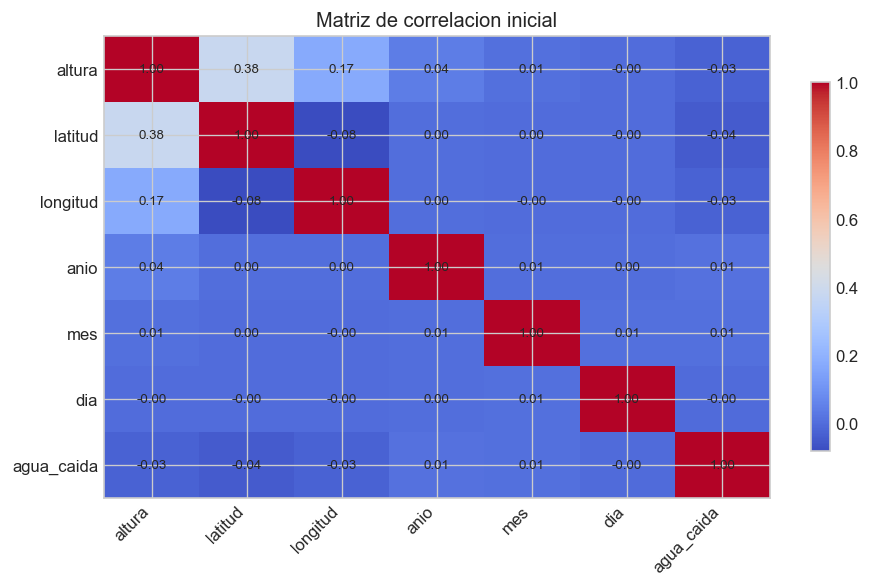

In [18]:
heatmap_df(
    corr_inicial,
    "Matriz de correlacion inicial",
    cmap="coolwarm",
    figsize=(8, 5),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La matriz de correlacion inicial muestra relaciones lineales muy debiles entre `agua_caida` y las variables numericas disponibles en su forma bruta. La asociacion de mayor magnitud absoluta corresponde a `latitud` (-0.044), seguida por `altura` (-0.026) y `longitud` (-0.025), mientras que `anio`, `mes` y `dia` presentan coeficientes cercanos a cero. Esto sugiere que, a nivel diario, la precipitacion no queda bien representada por relaciones lineales simples y que sera necesario construir variables mas expresivas para capturar su comportamiento temporal y territorial.


### 2.7 Patrones/comportamientos detectados


Mas alla de la correlacion lineal, el entendimiento de los datos exige observar patrones concretos en el tiempo y en el espacio. En esta subseccion se resume la precipitacion por mes, por anio y por region, con el proposito de identificar comportamientos recurrentes, periodos de mayor intensidad y diferencias sistematicas entre zonas del pais.


In [ ]:
lluvia_mensual = (
    df_modelo.groupby("mes")["agua_caida"]
    .agg(media="mean", suma="sum", maximo="max")
    .round(2)
)

display(lluvia_mensual)


El resumen mensual permite detectar estacionalidad. A continuacion se agrega el consolidado anual para observar si existen cambios recientes en el volumen total de precipitacion del conjunto.


In [ ]:
lluvia_anual = (
    df_modelo.groupby("anio")["agua_caida"]
    .agg(media="mean", suma="sum", maximo="max")
    .round(2)
)

display(lluvia_anual)


Aqui se observa la dimension temporal agregada. El resumen mensual ayuda a detectar estacionalidad, mientras que el anual permite ver si existen cambios recientes en el comportamiento del conjunto completo.


In [ ]:
frecuencia_region = (
    df_modelo.assign(tiene_lluvia=df_modelo["agua_caida"] > 0)
    .groupby("nombre_region")["tiene_lluvia"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(frecuencia_region.head(10))


Primero se resume la frecuencia de dias con lluvia por region. Esto muestra en que zonas la precipitacion aparece con mayor regularidad, independiente de si los montos son altos o bajos.


In [ ]:
top_estaciones = (
    df_modelo.groupby("nombre_estacion")
    .agg(
        media_lluvia=("agua_caida", "mean"),
        frecuencia_lluvia=("agua_caida", lambda s: (s > 0).mean() * 100),
        region=("nombre_region", "first"),
    )
    .sort_values("frecuencia_lluvia", ascending=False)
    .round(2)
)

display(top_estaciones.head(10))


Con este segundo bloque la mirada se desplaza hacia el territorio. La frecuencia regional de lluvia y el ranking de estaciones ayudan a identificar si los patrones medios esconden diferencias locales importantes.


In [ ]:
patron_region_mes = (
    df_modelo.pivot_table(
        index="mes",
        columns="nombre_region",
        values="agua_caida",
        aggfunc="mean",
    )
    .round(2)
)

display(patron_region_mes)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lluvia_mensual["media"].plot(marker="o", ax=axes[0], color="#2563eb")
axes[0].set_title("Promedio diario por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Milimetros")

lluvia_anual["suma"].plot(kind="bar", ax=axes[1], color="#0f766e")
axes[1].set_title("Precipitacion total por anio")
axes[1].set_xlabel("Anio")
axes[1].set_ylabel("Milimetros acumulados")

plt.tight_layout()
plt.show()


Las visualizaciones temporales permiten reconocer estacionalidad e intensidad agregada por anio. Luego se agrega una vista territorial especifica para no mezclar ambas lecturas en una sola figura demasiado cargada.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
frecuencia_region.head(10).sort_values().plot(kind="barh", ax=ax, color="#f97316")
ax.set_title("Top 10 regiones por frecuencia de lluvia")
ax.set_xlabel("% de dias con lluvia")
ax.set_ylabel("Region")
plt.tight_layout()
plt.show()


In [ ]:
heatmap_df(
    patron_region_mes,
    "Promedio mensual por region",
    cmap="YlGnBu",
    figsize=(13, 6),
    decimals=1,
    xlabel="Region",
    ylabel="Mes",
    cbar_label="Milimetros promedio",
)


**Analisis.** A nivel agregado, esta lectura confirma una estacionalidad clara y diferencias espaciales muy marcadas. Los meses de invierno concentran los mayores promedios de precipitacion, mientras que el norte permanece seco gran parte del ano y el sur presenta una actividad mucho mas persistente. La combinacion de tablas y graficos muestra que el fenomeno no depende solo del calendario, sino tambien del territorio especifico donde se observa.


### 2.8 Nuevas variables a partir del analisis


A partir de los patrones detectados, resulta conveniente construir variables que representen mejor la naturaleza ciclica del tiempo y la agrupacion territorial de las estaciones. La finalidad de estas nuevas variables no es aumentar artificialmente la dimensionalidad, sino incorporar estructuras que las columnas originales no capturan de forma directa.


In [ ]:
estaciones = {
    12: "Verano", 1: "Verano", 2: "Verano",
    3: "Otono", 4: "Otono", 5: "Otono",
    6: "Invierno", 7: "Invierno", 8: "Invierno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}

df_features = df_modelo.copy()
df_features["estacion_anual"] = df_features["mes"].map(estaciones)
df_features["dia_del_anio"] = df_features["fecha"].dt.dayofyear

display(df_features[["fecha", "mes", "estacion_anual", "dia_del_anio"]].head(12))


El primer grupo de variables derivadas resume la posicion del registro dentro del calendario. Esto permite pasar de un tiempo crudo a una representacion mas interpretativa y cercana a la logica meteorologica.


In [ ]:
df_features["mes_sin"] = np.sin(2 * np.pi * df_features["mes"] / 12)
df_features["mes_cos"] = np.cos(2 * np.pi * df_features["mes"] / 12)
df_features["dia_sin"] = np.sin(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["dia_cos"] = np.cos(2 * np.pi * df_features["dia_del_anio"] / 365.25)
df_features["lluvia_evento"] = (df_features["agua_caida"] > 0).astype(int)
df_features["macrozona"] = df_features["region"].apply(region_to_macrozone)

display(
    df_features[
        [
            "fecha", "mes_sin", "mes_cos", "dia_sin", "dia_cos",
            "lluvia_evento", "macrozona"
        ]
    ].head(12)
)


**Analisis.** Las variables derivadas permiten representar de mejor manera la dinamica observada en la fase exploratoria. `estacion_anual` resume el calendario meteorologico, las componentes ciclicas evitan tratar el tiempo como una escala lineal simple, `lluvia_evento` separa ocurrencia de intensidad y `macrozona` sintetiza diferencias territoriales de mayor escala. En conjunto, estas variables quedan mejor alineadas con la naturaleza del fenomeno que las columnas originales por si solas.


### 2.9 Matriz de Correlacion


Con las nuevas variables disponibles, se recalcula la matriz de correlacion utilizando `agua_caida_log` como referencia analitica. Esta decision permite reducir el efecto de la asimetria extrema de la variable objetivo y facilita una lectura mas interpretable de las asociaciones lineales entre la precipitacion y las variables derivadas.


In [ ]:
corr_extendida = df_features[
    [
        "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos",
        "dia_sin", "dia_cos", "lluvia_evento", "agua_caida_log"
    ]
].copy()

for macrozona in ["Norte", "Centro", "Sur", "Austral"]:
    corr_extendida[f"macrozona_{macrozona.lower()}"] = (df_features["macrozona"] == macrozona).astype(int)

display(corr_extendida.head())


Antes de calcular la correlacion conviene revisar explicitamente la matriz de trabajo. Asi se observa que la correlacion extendida no se limita a columnas originales, sino que incorpora variables ciclicas, un indicador de ocurrencia de lluvia y la pertenencia a macrozonas.


In [ ]:
matriz_corr_extendida = corr_extendida.corr(numeric_only=True).round(3)

display(matriz_corr_extendida)
display(matriz_corr_extendida["agua_caida_log"].sort_values(ascending=False))


In [ ]:
heatmap_df(
    matriz_corr_extendida,
    "Matriz de correlacion con nuevas variables",
    cmap="coolwarm",
    figsize=(11, 7),
    decimals=2,
    xlabel="Variables",
    ylabel="Variables",
    cbar_label="Correlacion",
)


**Analisis.** La nueva matriz resulta bastante mas interpretable que la inicial. La variable `lluvia_evento` suele concentrar la asociacion positiva mas fuerte con `agua_caida_log`, mientras que latitud, macrozona y componentes ciclicas ayudan a capturar la estructura territorial y temporal del fenomeno. En otras palabras, la incorporacion de variables derivadas logra representar mejor la precipitacion diaria que la correlacion construida solo con variables crudas.


### 2.10 Patrones/comportamientos detectados con nuevas variables


Finalmente, se revisa si las variables creadas ayudan a revelar patrones mas claros en la precipitacion diaria. En particular, interesa observar como cambia el comportamiento entre macrozonas y estaciones del ano, tanto en intensidad media como en frecuencia de dias con lluvia.


In [ ]:
orden_estaciones = ["Verano", "Otono", "Invierno", "Primavera"]

patron_macrozona = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="macrozona",
        values="agua_caida",
        aggfunc="mean",
    )
    .reindex(orden_estaciones)
    .round(2)
)

display(patron_macrozona)


El promedio por macrozona y estacion permite observar la intensidad tipica de la lluvia una vez que el territorio se agrupa a una escala mas amplia. Esto ayuda a simplificar la lectura sin perder la diferencia entre norte, centro, sur y zona austral.


In [ ]:
frecuencia_macrozona = (
    df_features.pivot_table(
        index="estacion_anual",
        columns="macrozona",
        values="lluvia_evento",
        aggfunc="mean",
    )
    .reindex(orden_estaciones)
    .mul(100)
    .round(2)
)

display(frecuencia_macrozona)


La frecuencia complementa al promedio porque una macrozona puede tener lluvia intensa en pocos dias o lluvia moderada en muchos dias. Mirar ambas dimensiones en paralelo evita conclusiones incompletas.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
patron_macrozona.plot(kind="bar", ax=ax, color=["#2563eb", "#0f766e", "#f97316", "#8b5cf6"])
ax.set_title("Promedio de agua_caida por macrozona y estacion")
ax.set_xlabel("Estacion del ano")
ax.set_ylabel("Milimetros")
ax.legend(title="Macrozona")
plt.tight_layout()
plt.show()


In [ ]:
heatmap_df(
    frecuencia_macrozona,
    "Frecuencia de lluvia por macrozona y estacion",
    cmap="YlGnBu",
    figsize=(7, 4),
    decimals=1,
    xlabel="Macrozona",
    ylabel="Estacion del ano",
    cbar_label="% de dias con lluvia",
)


**Analisis.** Las nuevas variables permiten distinguir con mayor claridad comportamientos climaticos diferenciados. Al agrupar por macrozona y estacion del ano, la lectura se vuelve mas limpia y muestra con mayor nitidez que el sur y la zona austral concentran mas precipitacion y mayor frecuencia de lluvia, mientras que el norte mantiene un comportamiento mucho mas seco. Esto confirma que las variables creadas agregan valor analitico real y no solo complejidad adicional.


## 3. Transformacion

En esta fase se consolidan las transformaciones necesarias para dejar la base en una forma apta para etapas posteriores de modelamiento. El foco ya no esta en descubrir patrones nuevos, sino en traducir lo aprendido en la fase 2 a una representacion numerica, trazable y metodologicamente consistente.

### 3.1 Escalamiento

El escalamiento se concentra en las variables continuas, pero se implementa junto con tres resguardos metodologicos. Primero, se preserva la trazabilidad de los registros imputados para no tratar estimaciones como observaciones reales. Segundo, el `StandardScaler` se ajusta solo sobre un bloque temporal de referencia, reduciendo el riesgo de fuga de informacion. Tercero, las variables categoricas derivadas se codifican sin redundancia perfecta, dejando una matriz mas estable para las tecnicas de modelamiento posteriores.


In [ ]:
resumen_objetivo_modelado = pd.DataFrame(
    {
        "filas_totales_en_df_features": [len(df_features)],
        "filas_con_target_observado": [int((df_features["agua_caida_imputada"] == 0).sum())],
        "filas_con_target_imputado": [int((df_features["agua_caida_imputada"] == 1).sum())],
    }
)

display(resumen_objetivo_modelado)


**Depuracion del subconjunto supervisado.** Antes de escalar, se identifica el subconjunto que puede utilizarse como base supervisada sin ambiguedad. Los registros con `agua_caida_imputada = 1` siguen siendo utiles para analisis descriptivo, pero no conviene tratarlos como valores observados al preparar entrenamiento y evaluacion.


In [ ]:
corte_temporal = pd.Timestamp("2025-01-01")

df_supervisado = (
    df_features.loc[df_features["agua_caida_imputada"] == 0]
    .sort_values("fecha")
    .copy()
)

df_train_ref = df_supervisado.loc[df_supervisado["fecha"] < corte_temporal].copy()
df_test_ref = df_supervisado.loc[df_supervisado["fecha"] >= corte_temporal].copy()

resumen_split = pd.DataFrame(
    {
        "bloque": ["train_referencia", "test_referencia"],
        "filas": [len(df_train_ref), len(df_test_ref)],
        "fecha_min": [df_train_ref["fecha"].min().date(), df_test_ref["fecha"].min().date()],
        "fecha_max": [df_train_ref["fecha"].max().date(), df_test_ref["fecha"].max().date()],
    }
)

display(resumen_split)


**Corte temporal de referencia.** Se utiliza `2025-01-01` como punto de separacion porque el dataset cubre entre 2021 y 2025 y conviene respetar su secuencia cronologica. Asi, el bloque 2021-2024 sirve para ajustar transformaciones y el ano 2025 queda como referencia posterior, evitando que el escalamiento incorpore informacion del periodo mas reciente.


In [ ]:
columnas_continuas = [
    "altura", "latitud", "longitud", "anio", "mes_sin", "mes_cos", "dia_sin", "dia_cos"
]

resumen_pre_escalado = df_train_ref[columnas_continuas].agg(["mean", "std", "min", "max"]).T.round(3)
display(resumen_pre_escalado)


**Diagnostico de escala sobre el bloque de ajuste.** El resumen descriptivo se calcula sobre `train`, ya que ese es el subconjunto que efectivamente define los parametros del escalador. De este modo, el analisis previo y la transformacion posterior quedan alineados metodologicamente.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
resumen_pre_escalado["std"].sort_values().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_title("Dispersion original de variables continuas (train)")
ax.set_xlabel("Desviacion estandar")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()


**Analisis.** El grafico confirma que las variables continuas operan en escalas muy distintas incluso dentro del bloque de ajuste. `altura` domina claramente la dispersion, mientras que las componentes ciclicas trabajan en rangos mucho mas acotados. Si no se corrige esta diferencia, un algoritmo sensible a magnitudes tendera a privilegiar variables solo por su escala numerica y no necesariamente por su aporte real.


In [ ]:
escalador = StandardScaler()
columnas_escaladas = [f"{col}_z" for col in columnas_continuas]

valores_train_escalados = escalador.fit_transform(df_train_ref[columnas_continuas])
valores_test_escalados = escalador.transform(df_test_ref[columnas_continuas])

columnas_base = [
    "fecha", "codigo_estacion", "nombre_estacion", "nombre_region",
    "macrozona", "agua_caida", "agua_caida_imputada"
]

df_train_escalado = df_train_ref[columnas_base].copy()
df_test_escalado = df_test_ref[columnas_base].copy()

df_train_escalado[columnas_escaladas] = valores_train_escalados
df_test_escalado[columnas_escaladas] = valores_test_escalados

df_train_escalado["bloque_temporal"] = "train"
df_test_escalado["bloque_temporal"] = "test"
df_escalado = pd.concat([df_train_escalado, df_test_escalado], axis=0).sort_values("fecha").reset_index(drop=True)

resumen_post_escalado = df_train_escalado[columnas_escaladas].agg(["mean", "std", "min", "max"]).T.round(3)
display(resumen_post_escalado)


**Aplicacion del escalador.** Con `StandardScaler`, el ajuste se realiza solo con el bloque `train` y luego se aplica a `test` sin recalcular parametros. Esta decision evita una transformacion contaminada por informacion futura y deja la fase 3 alineada con un flujo de modelamiento mas realista.


In [ ]:
comparacion_escalamiento = pd.DataFrame(
    {
        "media_original_train": resumen_pre_escalado["mean"],
        "std_original_train": resumen_pre_escalado["std"],
        "media_escalada_train": resumen_post_escalado["mean"].values,
        "std_escalada_train": resumen_post_escalado["std"].values,
    },
    index=columnas_continuas,
).round(3)

display(comparacion_escalamiento)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

comparacion_escalamiento["std_original_train"].sort_values().plot(kind="barh", ax=axes[0], color="#f97316")
axes[0].set_title("Antes del escalamiento (train)")
axes[0].set_xlabel("Desviacion estandar")
axes[0].set_ylabel("Variable")

comparacion_escalamiento["std_escalada_train"].sort_values().plot(kind="barh", ax=axes[1], color="#0f766e")
axes[1].set_title("Despues del escalamiento (train)")
axes[1].set_xlabel("Desviacion estandar")
axes[1].set_ylabel("Variable")

plt.tight_layout()
plt.show()


**Analisis.** La comparacion antes y despues del escalamiento muestra que la transformacion no modifica la existencia de patrones, pero si vuelve comparable la contribucion potencial de cada predictor. En el bloque de ajuste, las medias quedan cercanas a cero y las desviaciones estandar se aproximan a uno, lo que confirma que la estandarizacion se aplico correctamente sin mezclar informacion del bloque temporal posterior.


In [ ]:
dummies_train = pd.get_dummies(
    df_train_escalado["macrozona"], prefix="macrozona", dtype=int, drop_first=True
)
dummies_test = pd.get_dummies(
    df_test_escalado["macrozona"], prefix="macrozona", dtype=int, drop_first=True
).reindex(columns=dummies_train.columns, fill_value=0)

X_train_preparado = pd.concat([df_train_escalado[columnas_escaladas], dummies_train], axis=1)
X_test_preparado = pd.concat([df_test_escalado[columnas_escaladas], dummies_test], axis=1)
y_train_objetivo = df_train_escalado["agua_caida"].copy()
y_test_objetivo = df_test_escalado["agua_caida"].copy()

resumen_modelado = pd.DataFrame(
    {
        "bloque": ["train", "test"],
        "filas_X": [len(X_train_preparado), len(X_test_preparado)],
        "filas_y": [len(y_train_objetivo), len(y_test_objetivo)],
        "targets_imputados_en_bloque": [
            int(df_train_escalado["agua_caida_imputada"].sum()),
            int(df_test_escalado["agua_caida_imputada"].sum()),
        ],
        "columnas_X": [X_train_preparado.shape[1], X_test_preparado.shape[1]],
    }
)

display(resumen_modelado)
display(X_train_preparado.head())


**Construccion del set final.** La fase 3 deja una base considerablemente mas robusta que la version inicial. `y_train_objetivo` y `y_test_objetivo` se construyen solo con precipitaciones observadas, el escalamiento se ajusta sin fuga de informacion y las dummies de `macrozona` se generan con una categoria base omitida para evitar colinealidad perfecta. En consecuencia, la salida de esta fase ya no es solo una transformacion descriptiva, sino una preparacion coherente para separar entrenamiento y prueba, comparar modelos y avanzar hacia la fase de modelamiento.
